# Análise Long Neck NENO — Ambev Case
### Gráficos de Análise Univariada


In [1]:
# Importações e configuração visual padrão
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Paleta customizada Ambev
AMBEV_YELLOW = '#FFB800'
AMBEV_DARK = '#1A1A1A'
AMBEV_BLUE = '#4169E1'
AMBEV_RED = '#C0392B'
AMBEV_GREEN = '#27AE60'


## 1. Carregamento dos Dados
Leitura de todas as abas do arquivo Excel convertido (.xlsx).

In [2]:
# Carrega todas as abas relevantes do arquivo
file_path = '/Users/gustavopacheco/Downloads/PS JR/Analise_LongNeck_WSNP_-_Sem_repostas.xlsx'

cenario_br = pd.read_excel(file_path, sheet_name='Cenário atual BR', header=None, engine='calamine')
custos = pd.read_excel(file_path, sheet_name='Custos de transferência', header=None, engine='calamine')
producao_pcp = pd.read_excel(file_path, sheet_name='Produção PCP', header=None, engine='calamine')
transf_prog = pd.read_excel(file_path, sheet_name='Transferências Programadas', header=None, engine='calamine')
cenario_div = pd.read_excel(file_path, sheet_name='Cenário Divulgado', header=None, engine='calamine')
cenario_novo = pd.read_excel(file_path, sheet_name='Cenário com Nova Demanda', header=None, engine='calamine')

print("Abas carregadas com sucesso!")
for name, df in [('Cenário BR', cenario_br), ('Custos', custos), 
                  ('Produção PCP', producao_pcp), ('Transf. Prog.', transf_prog),
                  ('Cenário Divulgado', cenario_div), ('Cenário Nova Demanda', cenario_novo)]:
    print(f"  {name}: {df.shape[0]} linhas x {df.shape[1]} colunas")

Abas carregadas com sucesso!
  Cenário BR: 25 linhas x 24 colunas
  Custos: 23 linhas x 5 colunas
  Produção PCP: 16 linhas x 10 colunas
  Transf. Prog.: 8 linhas x 11 colunas
  Cenário Divulgado: 49 linhas x 48 colunas
  Cenário Nova Demanda: 49 linhas x 48 colunas


## 2. Demanda por Região — Cenário Brasil (Janeiro)
Distribuição da demanda total de Long Neck entre as regionais do Brasil, destacando o peso do NENO.


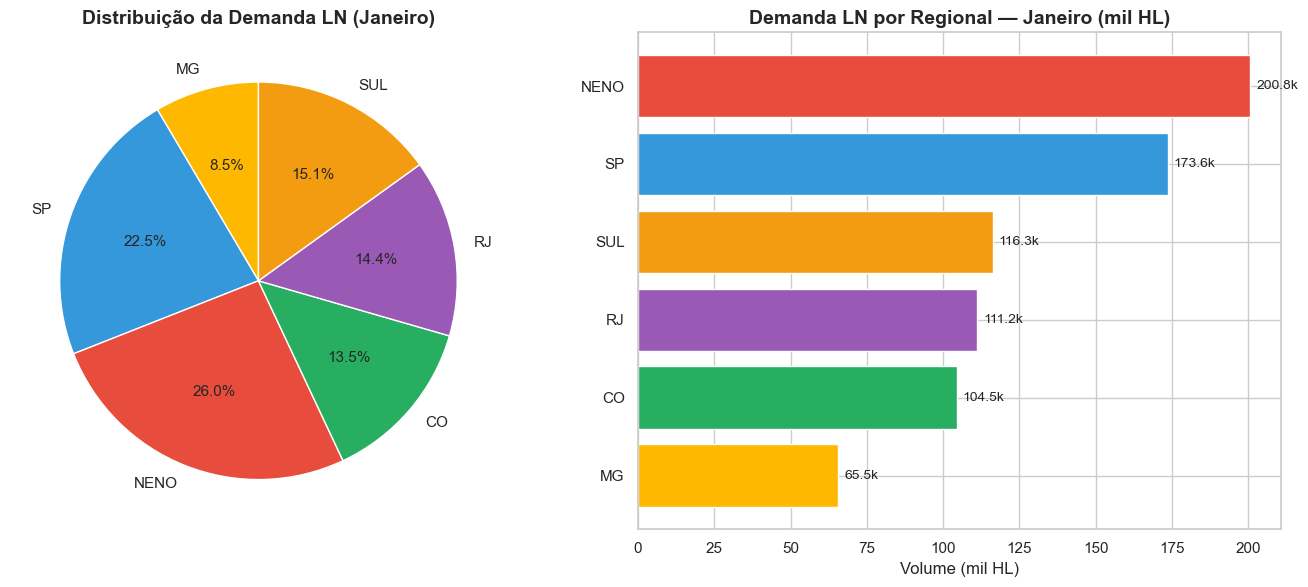

In [3]:
# Cenário atual BR — Demanda Janeiro (lido da aba 'Cenário atual BR')
regioes = ['MG', 'SP', 'NENO', 'CO', 'RJ', 'SUL']
demanda_jan = [
    cenario_br.iloc[5, 3],   # MG
    cenario_br.iloc[6, 3],   # SP
    cenario_br.iloc[7, 3],   # NENO
    cenario_br.iloc[8, 3],   # CO
    cenario_br.iloc[9, 3],   # RJ
    cenario_br.iloc[10, 3],  # SUL
]

colors = [AMBEV_YELLOW, '#3498DB', '#E74C3C', AMBEV_GREEN, '#9B59B6', '#F39C12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = ax1.pie(demanda_jan, labels=regioes, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribuição da Demanda LN (Janeiro)', fontsize=14, fontweight='bold')

sorted_idx = np.argsort(demanda_jan)
ax2.barh([regioes[i] for i in sorted_idx], [demanda_jan[i]/1000 for i in sorted_idx],
         color=[colors[i] for i in sorted_idx], edgecolor='white')
ax2.set_xlabel('Volume (mil HL)')
ax2.set_title('Demanda LN por Regional — Janeiro (mil HL)', fontsize=14, fontweight='bold')
for i, idx in enumerate(sorted_idx):
    ax2.text(demanda_jan[idx]/1000 + 2, i, f'{demanda_jan[idx]/1000:.1f}k', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Custos de Transferência e Produção
Comparação entre custo de transferência (SP → NE via cabotagem), MACO e custo de produção por SKU.


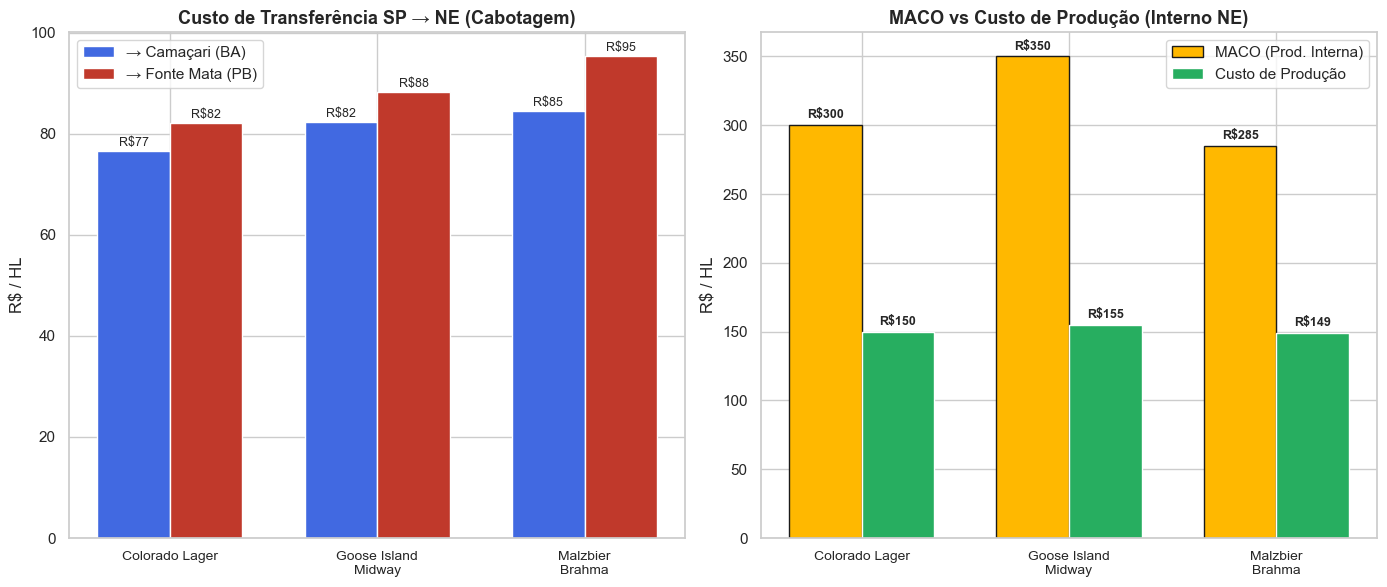

In [4]:
# Custos — lidos da aba 'Custos de transferência'
skus_short = ['Colorado Lager', 'Goose Island\nMidway', 'Malzbier\nBrahma']

transf_camacari  = [custos.iloc[3, 4], custos.iloc[5, 4], custos.iloc[6, 4]]  # → Camaçari
transf_fonte_mata = [custos.iloc[4, 4], custos.iloc[7, 4], custos.iloc[8, 4]]  # → Fonte Mata
maco      = [custos.iloc[13, 4], custos.iloc[14, 4], custos.iloc[15, 4]]
custo_prod = [custos.iloc[20, 4], custos.iloc[21, 4], custos.iloc[22, 4]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(3)
w = 0.35

ax1.bar(x - w/2, transf_camacari,  w, label='→ Camaçari (BA)', color=AMBEV_BLUE)
ax1.bar(x + w/2, transf_fonte_mata, w, label='→ Fonte Mata (PB)', color=AMBEV_RED)
ax1.set_xticks(x); ax1.set_xticklabels(skus_short, fontsize=10)
ax1.set_ylabel('R$ / HL')
ax1.set_title('Custo de Transferência SP → NE (Cabotagem)', fontsize=13, fontweight='bold')
ax1.legend()
for i in range(3):
    ax1.text(i - w/2, transf_camacari[i]  + 1, f'R${transf_camacari[i]:.0f}',  ha='center', fontsize=9)
    ax1.text(i + w/2, transf_fonte_mata[i] + 1, f'R${transf_fonte_mata[i]:.0f}', ha='center', fontsize=9)

ax2.bar(x - w/2, maco,       w, label='MACO (Prod. Interna)', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
ax2.bar(x + w/2, custo_prod, w, label='Custo de Produção',    color=AMBEV_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(skus_short, fontsize=10)
ax2.set_ylabel('R$ / HL')
ax2.set_title('MACO vs Custo de Produção (Interno NE)', fontsize=13, fontweight='bold')
ax2.legend()
for i in range(3):
    ax2.text(i - w/2, maco[i]       + 5, f'R${maco[i]:.0f}',       ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, custo_prod[i] + 5, f'R${custo_prod[i]:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Impacto do Aumento de Demanda — Malzbier Brahma (Total NENO)
Comparação da demanda semanal total (NENO) entre o cenário divulgado e o cenário com nova demanda.

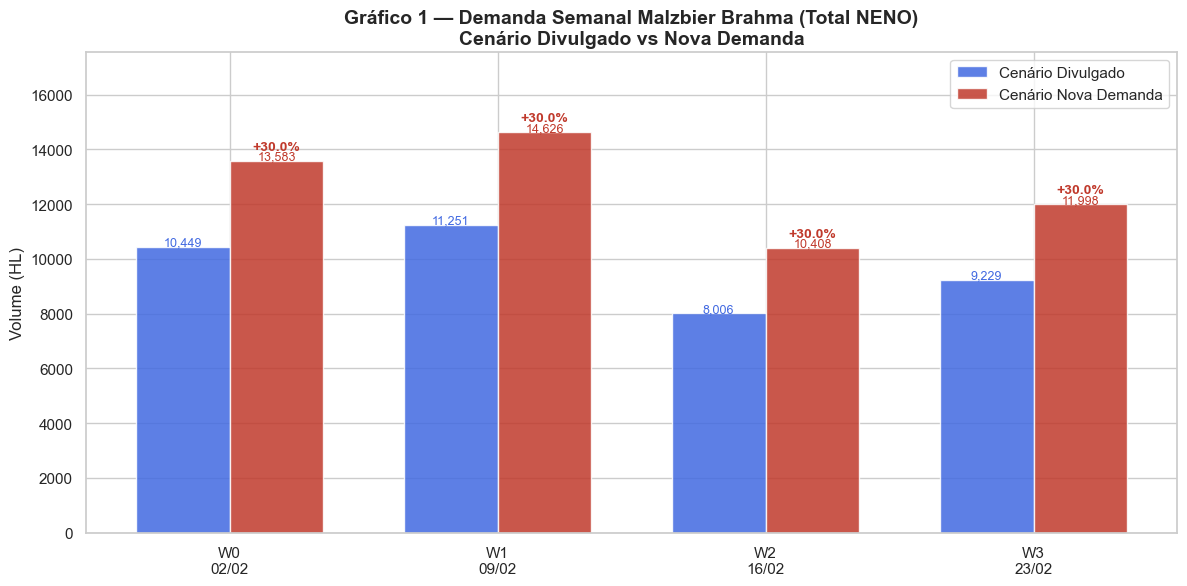


📊 INSIGHT: A nova demanda representa um aumento de 11,680 HL no mês (+30.0%).
   Demanda total divulgada: 38,934 HL → Nova demanda: 50,614 HL


In [5]:
# Gráfico 1: Demanda semanal Malzbier TOTAL — Divulgado vs Nova Demanda
semanas = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

# Malzbier TOTAL row = 25 (divulgado) e 25 (nova demanda)
malz_div_total = [cenario_div.iloc[25, 3], cenario_div.iloc[25, 16], cenario_div.iloc[25, 27], cenario_div.iloc[25, 38]]
malz_nova_total = [cenario_novo.iloc[25, 3], cenario_novo.iloc[25, 16], cenario_novo.iloc[25, 27], cenario_novo.iloc[25, 38]]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
w = 0.35

bars1 = ax.bar(x - w/2, malz_div_total, w, label='Cenário Divulgado', color=AMBEV_BLUE, alpha=0.85)
bars2 = ax.bar(x + w/2, malz_nova_total, w, label='Cenário Nova Demanda', color=AMBEV_RED, alpha=0.85)

for i in range(4):
    diff_pct = (malz_nova_total[i] - malz_div_total[i]) / malz_div_total[i] * 100
    ax.annotate(f'+{diff_pct:.1f}%', xy=(x[i] + w/2, malz_nova_total[i]),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=10,
                fontweight='bold', color=AMBEV_RED)
    ax.text(x[i] - w/2, malz_div_total[i] + 50, f'{malz_div_total[i]:,.0f}', ha='center', fontsize=9, color=AMBEV_BLUE)
    ax.text(x[i] + w/2, malz_nova_total[i] + 50, f'{malz_nova_total[i]:,.0f}', ha='center', fontsize=9, color=AMBEV_RED)

ax.set_xticks(x); ax.set_xticklabels(semanas)
ax.set_ylabel('Volume (HL)')
ax.set_title('Gráfico 1 — Demanda Semanal Malzbier Brahma (Total NENO)\nCenário Divulgado vs Nova Demanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(malz_nova_total) * 1.2)

plt.tight_layout()
plt.show()

aumento_total = sum(malz_nova_total) - sum(malz_div_total)
pct_total = aumento_total / sum(malz_div_total) * 100
print(f"\n📊 INSIGHT: A nova demanda representa um aumento de {aumento_total:,.0f} HL no mês (+{pct_total:.1f}%).")
print(f"   Demanda total divulgada: {sum(malz_div_total):,.0f} HL → Nova demanda: {sum(malz_nova_total):,.0f} HL")

## 6. Aumento de Demanda por Sub-Região (GEO) — Malzbier Brahma
Qual sub-região do NENO é mais impactada pelo aumento de demanda?

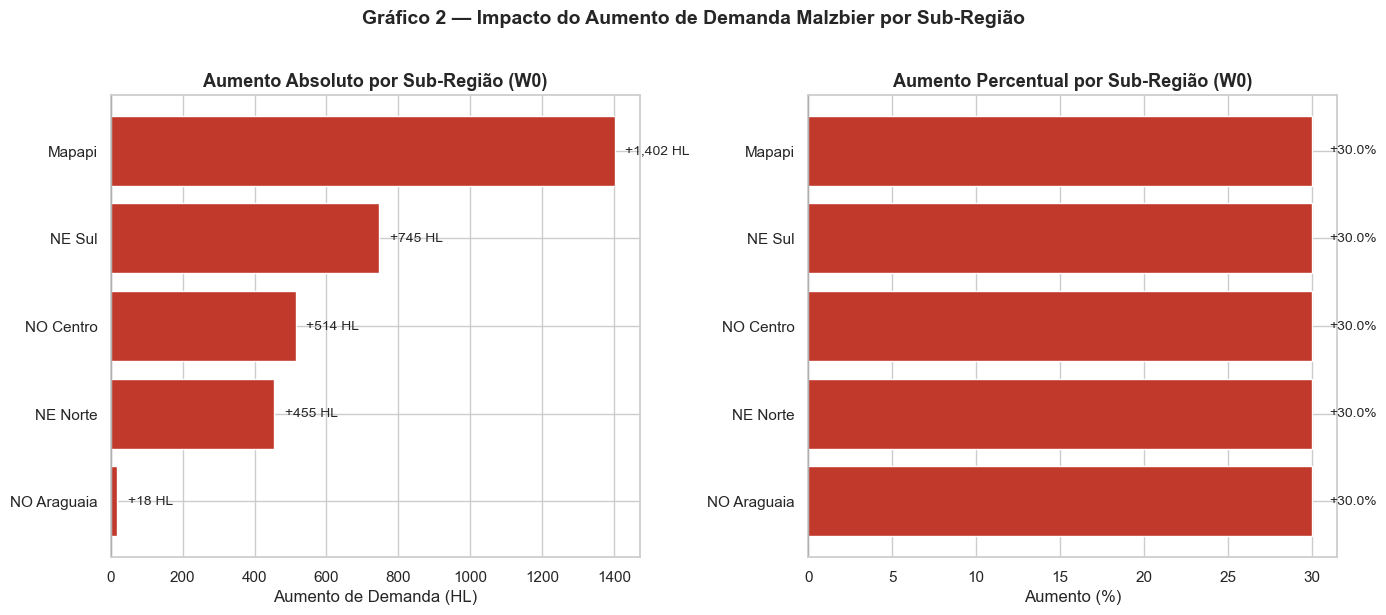


📊 INSIGHT: A sub-região 'Mapapi' concentra o maior aumento absoluto de demanda (+1,402 HL).
   Todas as sub-regiões tiveram aumento, com destaque para Mapapi e NO Centro.


In [6]:
# Gráfico 2: Aumento absoluto e percentual de demanda Malzbier por sub-região (W0)
geos = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro']
rows_malz = [20, 21, 22, 23, 24]

dem_div_w0 = [cenario_div.iloc[r, 3] for r in rows_malz]
dem_nova_w0 = [cenario_novo.iloc[r, 3] for r in rows_malz]
aumento_abs = [n - d for n, d in zip(dem_nova_w0, dem_div_w0)]
aumento_pct = [(n - d) / d * 100 for n, d in zip(dem_nova_w0, dem_div_w0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Aumento absoluto
colors_bar = [AMBEV_RED if a > 0 else AMBEV_GREEN for a in aumento_abs]
sorted_idx = np.argsort(aumento_abs)
ax1.barh([geos[i] for i in sorted_idx], [aumento_abs[i] for i in sorted_idx],
         color=[colors_bar[i] for i in sorted_idx], edgecolor='white')
ax1.set_xlabel('Aumento de Demanda (HL)')
ax1.set_title('Aumento Absoluto por Sub-Região (W0)', fontsize=13, fontweight='bold')
for i, idx in enumerate(sorted_idx):
    ax1.text(aumento_abs[idx] + (30 if aumento_abs[idx] >= 0 else -30), i,
             f'{aumento_abs[idx]:+,.0f} HL', va='center', fontsize=10,
             ha='left' if aumento_abs[idx] >= 0 else 'right')
ax1.axvline(x=0, color='black', linewidth=0.8)

# Aumento percentual
ax2.barh([geos[i] for i in sorted_idx], [aumento_pct[i] for i in sorted_idx],
         color=[colors_bar[i] for i in sorted_idx], edgecolor='white')
ax2.set_xlabel('Aumento (%)')
ax2.set_title('Aumento Percentual por Sub-Região (W0)', fontsize=13, fontweight='bold')
for i, idx in enumerate(sorted_idx):
    ax2.text(aumento_pct[idx] + (1 if aumento_pct[idx] >= 0 else -1), i,
             f'{aumento_pct[idx]:+.1f}%', va='center', fontsize=10,
             ha='left' if aumento_pct[idx] >= 0 else 'right')
ax2.axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Gráfico 2 — Impacto do Aumento de Demanda Malzbier por Sub-Região', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

max_geo = geos[np.argmax(aumento_abs)]
print(f"\n📊 INSIGHT: A sub-região '{max_geo}' concentra o maior aumento absoluto de demanda ({max(aumento_abs):+,.0f} HL).")
print(f"   Todas as sub-regiões tiveram aumento, com destaque para Mapapi e NO Centro.")

## 7. Suficiência Final (dias) — Malzbier Brahma por Sub-Região
Evolução semanal da suficiência de estoque em dias sob o cenário de nova demanda. Valores abaixo de 0 indicam ruptura.

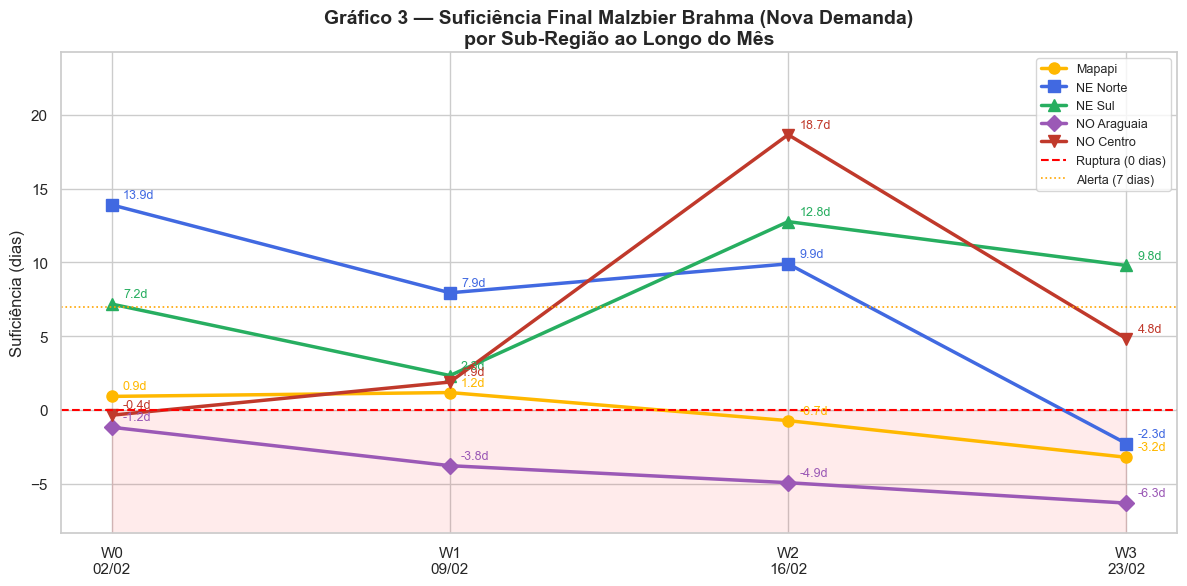


📊 INSIGHT: Sub-regiões que atingem ruptura (suficiência < 0 dias) no cenário de nova demanda:
   ⚠️ Mapapi: -0.7 dias em W2 16/02
   ⚠️ Mapapi: -3.2 dias em W3 23/02
   ⚠️ NE Norte: -2.3 dias em W3 23/02
   ⚡ NE Sul: mínimo de 2.3 dias (risco)
   ⚠️ NO Araguaia: -1.2 dias em W0 02/02
   ⚠️ NO Araguaia: -3.8 dias em W1 09/02
   ⚠️ NO Araguaia: -4.9 dias em W2 16/02
   ⚠️ NO Araguaia: -6.3 dias em W3 23/02
   ⚠️ NO Centro: -0.4 dias em W0 02/02


In [7]:
# Gráfico 3: Suficiência final (dias) — Malzbier Nova Demanda por sub-região ao longo das semanas
# Suficiência final cols: W0=14, W1=25, W2=36, W3=47
suf_cols = [14, 25, 36, 47]

fig, ax = plt.subplots(figsize=(12, 6))
geo_colors = [AMBEV_YELLOW, AMBEV_BLUE, AMBEV_GREEN, '#9B59B6', AMBEV_RED]
markers = ['o', 's', '^', 'D', 'v']

for i, (geo, row) in enumerate(zip(geos, rows_malz)):
    suf_vals = [cenario_novo.iloc[row, c] for c in suf_cols]
    ax.plot(semanas, suf_vals, marker=markers[i], linewidth=2.5, markersize=8,
            label=geo, color=geo_colors[i])
    for j, v in enumerate(suf_vals):
        ax.annotate(f'{v:.1f}d', (semanas[j], v), textcoords='offset points',
                    xytext=(8, 5), fontsize=9, color=geo_colors[i])

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Ruptura (0 dias)')
ax.axhline(y=7, color='orange', linestyle=':', linewidth=1.2, label='Alerta (7 dias)')
ax.fill_between(semanas, -10, 0, color='red', alpha=0.08)

ax.set_ylabel('Suficiência (dias)')
ax.set_title('Gráfico 3 — Suficiência Final Malzbier Brahma (Nova Demanda)\npor Sub-Região ao Longo do Mês', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(min(-8, min([cenario_novo.iloc[r, c] for r in rows_malz for c in suf_cols]) - 2),
            max([cenario_novo.iloc[r, c] for r in rows_malz for c in suf_cols]) * 1.3)

plt.tight_layout()
plt.show()

# Identify regions with negative sufficiency
print("\n📊 INSIGHT: Sub-regiões que atingem ruptura (suficiência < 0 dias) no cenário de nova demanda:")
for i, (geo, row) in enumerate(zip(geos, rows_malz)):
    suf_vals = [cenario_novo.iloc[row, c] for c in suf_cols]
    negatives = [(s, v) for s, v in zip(semanas, suf_vals) if v < 0]
    if negatives:
        for s, v in negatives:
            print(f"   ⚠️ {geo}: {v:.1f} dias em {s.replace(chr(10), ' ')}")
    else:
        min_val = min(suf_vals)
        if min_val < 7:
            print(f"   ⚡ {geo}: mínimo de {min_val:.1f} dias (risco)")

## 8. Estoque Final Semanal — Malzbier Brahma (Total NENO)
Evolução do estoque final total no NENO: comparação entre cenário divulgado e nova demanda.

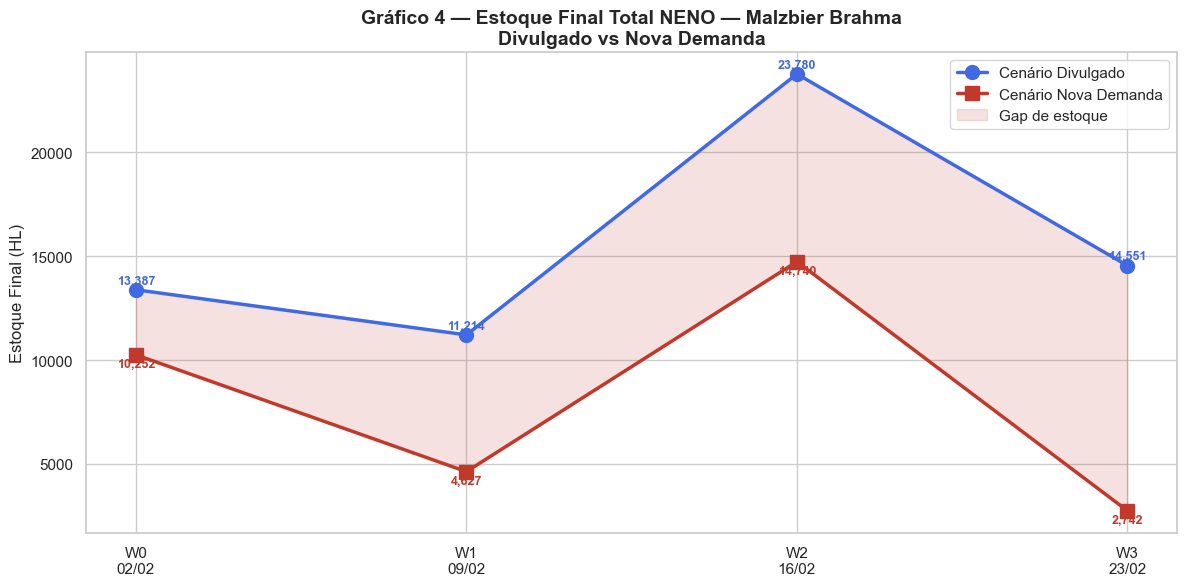


📊 INSIGHT: O gap médio de estoque entre os cenários é de 7,643 HL/semana.
   O estoque final cai significativamente com a nova demanda, aumentando risco de ruptura.


In [8]:
# Gráfico 4: Estoque Final Total NENO — Malzbier — Divulgado vs Nova Demanda
# EF Semana cols: W0=13, W1=24, W2=35, W3=46
ef_cols = [13, 24, 35, 46]
total_row = 25

ef_div = [cenario_div.iloc[total_row, c] for c in ef_cols]
ef_nova = [cenario_novo.iloc[total_row, c] for c in ef_cols]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(semanas, ef_div, marker='o', linewidth=2.5, markersize=10, label='Cenário Divulgado',
        color=AMBEV_BLUE)
ax.plot(semanas, ef_nova, marker='s', linewidth=2.5, markersize=10, label='Cenário Nova Demanda',
        color=AMBEV_RED)

# Área entre as duas curvas para mostrar gap
ax.fill_between(semanas, ef_nova, ef_div, alpha=0.15, color=AMBEV_RED, label='Gap de estoque')

for i in range(4):
    ax.text(semanas[i], ef_div[i] + 300, f'{ef_div[i]:,.0f}', ha='center', fontsize=9, color=AMBEV_BLUE, fontweight='bold')
    ax.text(semanas[i], ef_nova[i] - 600, f'{ef_nova[i]:,.0f}', ha='center', fontsize=9, color=AMBEV_RED, fontweight='bold')

ax.set_ylabel('Estoque Final (HL)')
ax.set_title('Gráfico 4 — Estoque Final Total NENO — Malzbier Brahma\nDivulgado vs Nova Demanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

gap_medio = np.mean([d - n for d, n in zip(ef_div, ef_nova)])
print(f"\n📊 INSIGHT: O gap médio de estoque entre os cenários é de {gap_medio:,.0f} HL/semana.")
print(f"   O estoque final cai significativamente com a nova demanda, aumentando risco de ruptura.")

## 9. Produção PCP Semanal — Malzbier Brahma (Fábricas NE)
Volume de produção programado (PCP) por fábrica e por semana para a Malzbier.

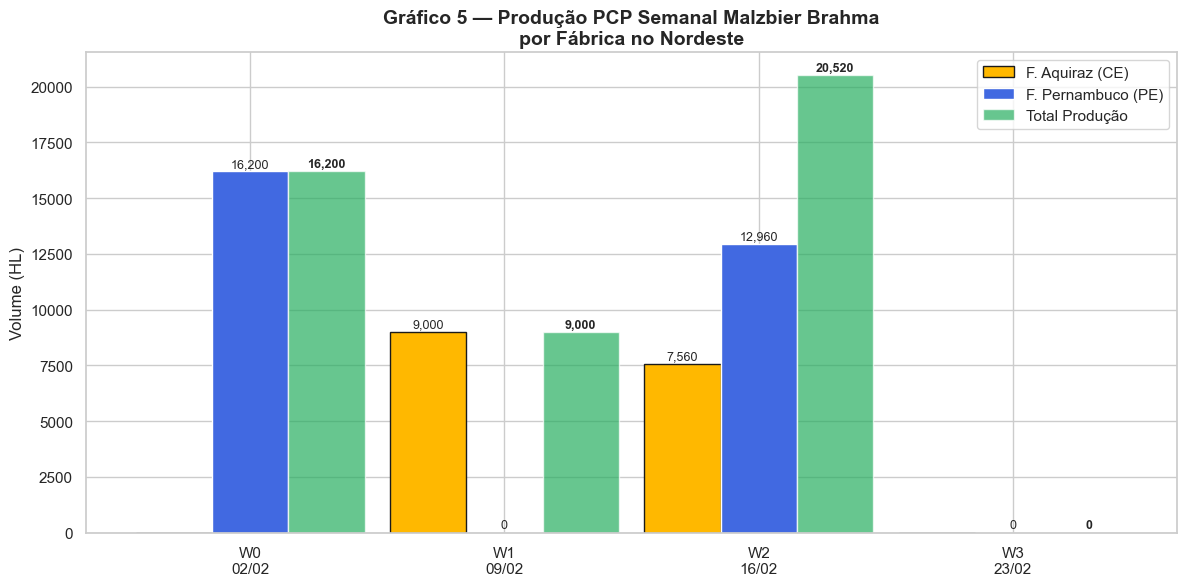


📊 INSIGHT: Produção total mensal programada: 45,720 HL.
   A produção é irregular — 1 semana(s) sem produção, criando gaps de abastecimento.
   Aquiraz produz apenas em W1-W2; Pernambuco apenas em W0 e W2.


In [9]:
# Gráfico 5: Produção PCP semanal da Malzbier por fábrica
# Aquiraz (CE) row 2, Pernambuco (PE) row 11
pcp_semanas_labels = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

malz_aquiraz = [producao_pcp.iloc[2, 6], producao_pcp.iloc[2, 7], producao_pcp.iloc[2, 8], producao_pcp.iloc[2, 9]]
malz_pernambuco = [producao_pcp.iloc[11, 6], producao_pcp.iloc[11, 7], producao_pcp.iloc[11, 8], producao_pcp.iloc[11, 9]]
malz_total_prod = [a + p for a, p in zip(malz_aquiraz, malz_pernambuco)]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
w = 0.3

ax.bar(x - w, malz_aquiraz, w, label='F. Aquiraz (CE)', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
ax.bar(x, malz_pernambuco, w, label='F. Pernambuco (PE)', color=AMBEV_BLUE)
ax.bar(x + w, malz_total_prod, w, label='Total Produção', color=AMBEV_GREEN, alpha=0.7)

for i in range(4):
    if malz_aquiraz[i] > 0:
        ax.text(x[i] - w, malz_aquiraz[i] + 200, f'{malz_aquiraz[i]:,.0f}', ha='center', fontsize=9)
    ax.text(x[i], malz_pernambuco[i] + 200, f'{malz_pernambuco[i]:,.0f}', ha='center', fontsize=9)
    ax.text(x[i] + w, malz_total_prod[i] + 200, f'{malz_total_prod[i]:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(pcp_semanas_labels)
ax.set_ylabel('Volume (HL)')
ax.set_title('Gráfico 5 — Produção PCP Semanal Malzbier Brahma\npor Fábrica no Nordeste', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

total_mensal = sum(malz_total_prod)
semanas_zero = sum(1 for t in malz_total_prod if t == 0)
print(f"\n📊 INSIGHT: Produção total mensal programada: {total_mensal:,.0f} HL.")
print(f"   A produção é irregular — {semanas_zero} semana(s) sem produção, criando gaps de abastecimento.")
print(f"   Aquiraz produz apenas em W1-W2; Pernambuco apenas em W0 e W2.")

## 10. Gap Demanda vs Produção — Malzbier Brahma (Nova Demanda)
A produção programada (WSNP) é suficiente para cobrir a nova demanda semanal?

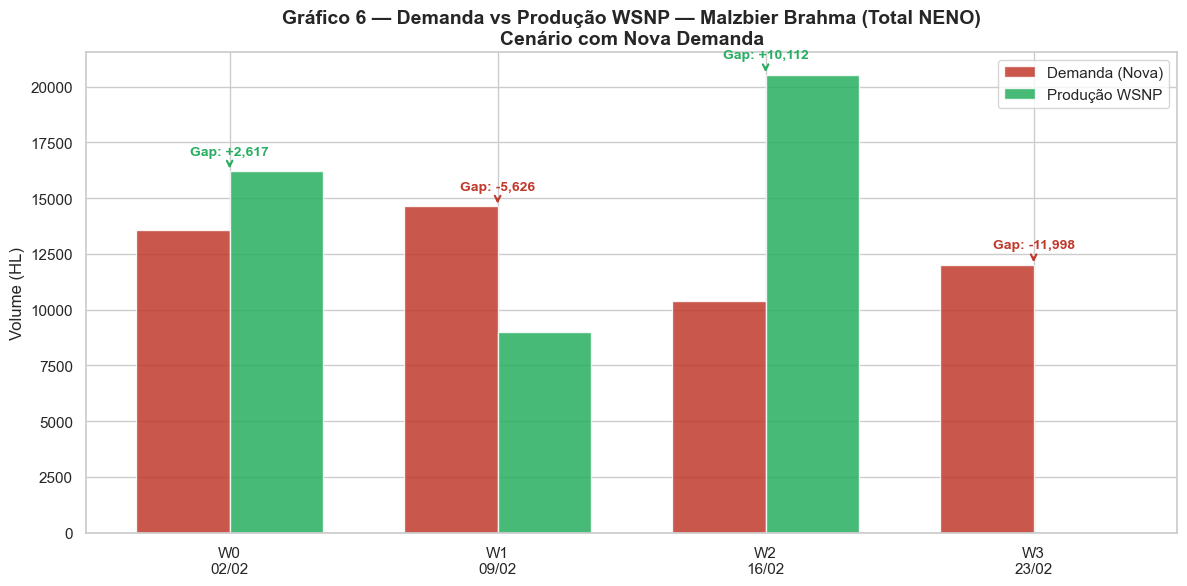


📊 INSIGHT: Gap acumulado no mês (Produção - Demanda): -4,894 HL.
   Semanas com déficit de produção: W1, W3
   A produção local (WSNP) depende fortemente de transferências para cobrir a demanda.


In [10]:
# Gráfico 6: Demanda total vs Produção WSNP — Malzbier Nova Demanda (NENO Total)
# WSNP cols: W0=5, W1=18, W2=29(col index in sheet), W3=40
wsnp_cols = [5, 18, 29, 40]
dem_cols = [3, 16, 27, 38]

dem_nova_semanal = [cenario_novo.iloc[total_row, c] for c in dem_cols]
wsnp_nova = [cenario_novo.iloc[total_row, c] for c in wsnp_cols]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
w = 0.35

ax.bar(x - w/2, dem_nova_semanal, w, label='Demanda (Nova)', color=AMBEV_RED, alpha=0.85)
ax.bar(x + w/2, wsnp_nova, w, label='Produção WSNP', color=AMBEV_GREEN, alpha=0.85)

gap = [p - d for p, d in zip(wsnp_nova, dem_nova_semanal)]
for i in range(4):
    color_gap = AMBEV_GREEN if gap[i] >= 0 else AMBEV_RED
    ax.annotate(f'Gap: {gap[i]:+,.0f}', xy=(x[i], max(dem_nova_semanal[i], wsnp_nova[i])),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=10,
                fontweight='bold', color=color_gap,
                arrowprops=dict(arrowstyle='->', color=color_gap, lw=1.5) if abs(gap[i]) > 1000 else None)

ax.set_xticks(x); ax.set_xticklabels(pcp_semanas_labels)
ax.set_ylabel('Volume (HL)')
ax.set_title('Gráfico 6 — Demanda vs Produção WSNP — Malzbier Brahma (Total NENO)\nCenário com Nova Demanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

deficit_total = sum(gap)
print(f"\n📊 INSIGHT: Gap acumulado no mês (Produção - Demanda): {deficit_total:+,.0f} HL.")
sem_deficit = [i for i, g in enumerate(gap) if g < 0]
if sem_deficit:
    print(f"   Semanas com déficit de produção: {', '.join(['W'+str(i) for i in sem_deficit])}")
print(f"   A produção local (WSNP) depende fortemente de transferências para cobrir a demanda.")

## 11. Capacidade Nominal vs Utilização — Linhas de Produção NE
Quanto da capacidade semanal das linhas está sendo utilizada? Há espaço para absorver o aumento?

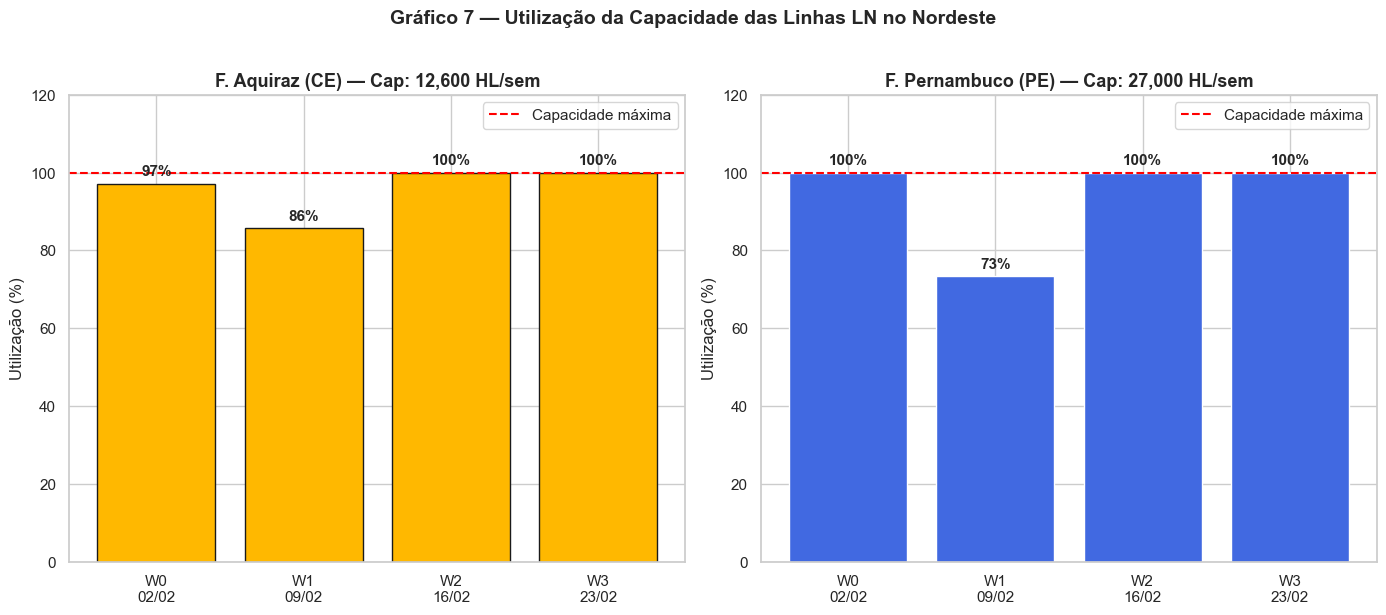


📊 INSIGHT: Capacidade ociosa acumulada no mês:
   Aquiraz: 2,160 HL (4% da cap. mensal)
   Pernambuco: 7,200 HL (7% da cap. mensal)
   Há espaço ocioso que poderia ser redirecionado para Malzbier.


In [11]:
# Gráfico 7: Utilização da capacidade por fábrica (todas as LN, não só Malzbier)
# Aquiraz: cap semanal = 12600 (row 2, col 3), uso total row 5
# Pernambuco: cap semanal = 27000 (row 9, col 3), uso total row 15
cap_aquiraz = producao_pcp.iloc[2, 3]  # 12600
cap_pernambuco = producao_pcp.iloc[9, 3]  # 27000

uso_aquiraz = [producao_pcp.iloc[5, c] for c in [6, 7, 8, 9]]
uso_pernambuco = [producao_pcp.iloc[15, c] for c in [6, 7, 8, 9]]

util_aquiraz = [u / cap_aquiraz * 100 for u in uso_aquiraz]
util_pernambuco = [u / cap_pernambuco * 100 for u in uso_pernambuco]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Aquiraz
bars1 = ax1.bar(pcp_semanas_labels, util_aquiraz, color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
ax1.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Capacidade máxima')
ax1.set_ylabel('Utilização (%)')
ax1.set_title(f'F. Aquiraz (CE) — Cap: {cap_aquiraz:,.0f} HL/sem', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 120)
ax1.legend()
for i, v in enumerate(util_aquiraz):
    ax1.text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')

# Pernambuco
bars2 = ax2.bar(pcp_semanas_labels, util_pernambuco, color=AMBEV_BLUE)
ax2.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Capacidade máxima')
ax2.set_ylabel('Utilização (%)')
ax2.set_title(f'F. Pernambuco (PE) — Cap: {cap_pernambuco:,.0f} HL/sem', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 120)
ax2.legend()
for i, v in enumerate(util_pernambuco):
    ax2.text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Gráfico 7 — Utilização da Capacidade das Linhas LN no Nordeste', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ocioso_aq = sum([(cap_aquiraz - u) for u in uso_aquiraz if u < cap_aquiraz])
ocioso_pe = sum([(cap_pernambuco - u) for u in uso_pernambuco if u < cap_pernambuco])
print(f"\n📊 INSIGHT: Capacidade ociosa acumulada no mês:")
print(f"   Aquiraz: {ocioso_aq:,.0f} HL ({ocioso_aq/cap_aquiraz/4*100:.0f}% da cap. mensal)")
print(f"   Pernambuco: {ocioso_pe:,.0f} HL ({ocioso_pe/cap_pernambuco/4*100:.0f}% da cap. mensal)")
print(f"   Há espaço ocioso que poderia ser redirecionado para Malzbier.")

## 12. Composição da Demanda NENO por SKU (W0) — Cenário Nova Demanda
Participação de cada SKU na demanda total da região NENO na primeira semana.

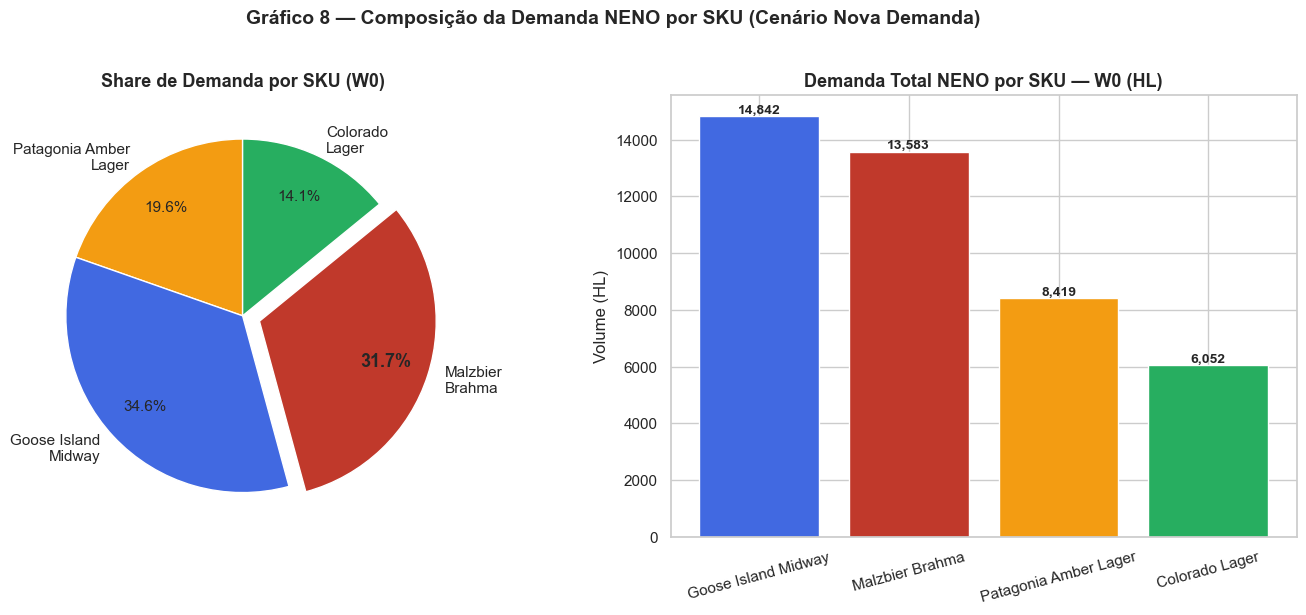


📊 INSIGHT: A Malzbier Brahma responde por 31.7% da demanda total NENO em W0.
   Com 13,583 HL, é o SKU de maior volume na região.


In [12]:
# Gráfico 8: Share de cada SKU na demanda total NENO (W0 - Nova Demanda)
skus = ['Patagonia Amber\nLager', 'Goose Island\nMidway', 'Malzbier\nBrahma', 'Colorado\nLager']
# Total rows: Patagonia=9, Goose=17, Malzbier=25, Colorado=33
total_rows_skus = [9, 17, 25, 33]

dem_skus_w0 = [cenario_novo.iloc[r, 3] for r in total_rows_skus]
dem_total_w0 = sum(dem_skus_w0)

colors_sku = ['#F39C12', AMBEV_BLUE, AMBEV_RED, AMBEV_GREEN]
explode = [0, 0, 0.1, 0]  # Destaca Malzbier

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = ax1.pie(dem_skus_w0, labels=skus, autopct='%1.1f%%',
                                    colors=colors_sku, explode=explode, startangle=90,
                                    textprops={'fontsize': 11}, pctdistance=0.75)
autotexts[2].set_fontweight('bold')
autotexts[2].set_fontsize(13)
ax1.set_title('Share de Demanda por SKU (W0)', fontsize=13, fontweight='bold')

# Barras absolutas
sorted_idx = np.argsort(dem_skus_w0)[::-1]
bars = ax2.bar([skus[i].replace('\n', ' ') for i in sorted_idx],
               [dem_skus_w0[i] for i in sorted_idx],
               color=[colors_sku[i] for i in sorted_idx], edgecolor='white')
ax2.set_ylabel('Volume (HL)')
ax2.set_title('Demanda Total NENO por SKU — W0 (HL)', fontsize=13, fontweight='bold')
for i, idx in enumerate(sorted_idx):
    ax2.text(i, dem_skus_w0[idx] + 100, f'{dem_skus_w0[idx]:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Gráfico 8 — Composição da Demanda NENO por SKU (Cenário Nova Demanda)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

malz_share = dem_skus_w0[2] / dem_total_w0 * 100
print(f"\n📊 INSIGHT: A Malzbier Brahma responde por {malz_share:.1f}% da demanda total NENO em W0.")
print(f"   Com {dem_skus_w0[2]:,.0f} HL, é o SKU de maior volume na região.")

## 13. Custo Unitário Malzbier — Transferência vs Produção Local
Análise do custo por HL para entender a viabilidade de transferir vs produzir localmente.

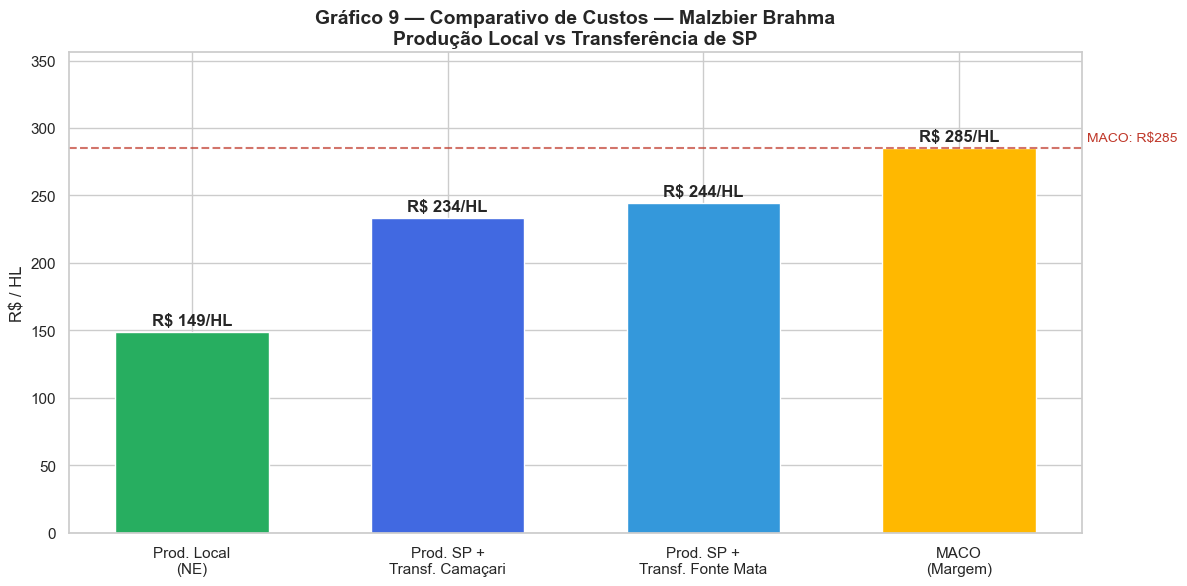


📊 INSIGHT: Produzir localmente (R$149/HL) é significativamente mais barato que transferir de SP.
   Transferir via Camaçari custa R$234/HL (diferença de R$85/HL).
   O MACO (R$285/HL) ainda cobre ambas alternativas, mas a margem cai com transferência.


In [13]:
# Gráfico 9: Comparativo de custos Malzbier — Waterfall
custos_malz = {
    'Produção Local\n(NE)': custos.iloc[22, 4],           # R$149/HL
    'MACO\n(Prod. Interna)': custos.iloc[15, 4],          # R$285/HL  
    'Transf. → Camaçari\n(Cabotagem)': custos.iloc[6, 4], # R$84.58/HL
    'Transf. → Fonte Mata\n(Cabotagem)': custos.iloc[8, 4] # R$95.33/HL
}

# Custo total para atender via transferência = produção SP + transporte
custo_prod_sp = custos.iloc[22, 4]  # mesmo custo base
custo_total_camacari = custo_prod_sp + custos.iloc[6, 4]
custo_total_fonte_mata = custo_prod_sp + custos.iloc[8, 4]

labels = ['Prod. Local\n(NE)', 'Prod. SP +\nTransf. Camaçari', 'Prod. SP +\nTransf. Fonte Mata', 'MACO\n(Margem)']
valores = [custos.iloc[22, 4], custo_total_camacari, custo_total_fonte_mata, custos.iloc[15, 4]]
colors_bar = [AMBEV_GREEN, AMBEV_BLUE, '#3498DB', AMBEV_YELLOW]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, valores, color=colors_bar, edgecolor='white', width=0.6)

for i, (bar, val) in enumerate(zip(bars, valores)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f'R$ {val:.0f}/HL',
            ha='center', fontsize=12, fontweight='bold')

# Linha de referência MACO
ax.axhline(y=custos.iloc[15, 4], color=AMBEV_RED, linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(3.5, custos.iloc[15, 4] + 5, f'MACO: R${custos.iloc[15, 4]:.0f}', fontsize=10, color=AMBEV_RED)

ax.set_ylabel('R$ / HL')
ax.set_title('Gráfico 9 — Comparativo de Custos — Malzbier Brahma\nProdução Local vs Transferência de SP', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(valores) * 1.25)

plt.tight_layout()
plt.show()

economia = custo_total_camacari - custos.iloc[22, 4]
print(f"\n📊 INSIGHT: Produzir localmente (R${custos.iloc[22, 4]:.0f}/HL) é significativamente mais barato que transferir de SP.")
print(f"   Transferir via Camaçari custa R${custo_total_camacari:.0f}/HL (diferença de R${economia:.0f}/HL).")
print(f"   O MACO (R${custos.iloc[15, 4]:.0f}/HL) ainda cobre ambas alternativas, mas a margem cai com transferência.")

## 14. Suficiência Total NENO — Comparativo entre SKUs (Nova Demanda)
Qual SKU está em situação mais crítica de estoque ao longo do mês?

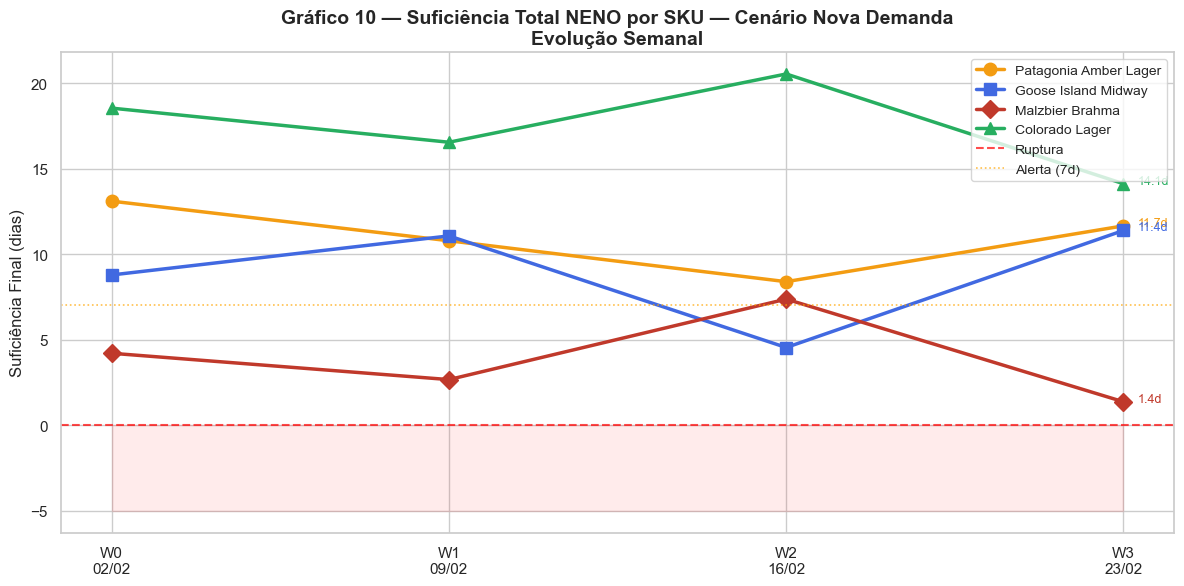


📊 INSIGHT: Comparativo de suficiência mínima por SKU no mês:
   ✅ OK Patagonia Amber Lager: mínimo de 8.4 dias
   ⚡ ALERTA Goose Island Midway: mínimo de 4.5 dias
   ⚠️ CRÍTICO Malzbier Brahma: mínimo de 1.4 dias
   ✅ OK Colorado Lager: mínimo de 14.1 dias

   A Malzbier Brahma é o SKU mais impactado, com a menor suficiência no cenário de nova demanda.


In [14]:
# Gráfico 10: Suficiência total NENO por SKU ao longo das semanas (Nova Demanda)
skus_labels = ['Patagonia Amber Lager', 'Goose Island Midway', 'Malzbier Brahma', 'Colorado Lager']
sku_colors = ['#F39C12', AMBEV_BLUE, AMBEV_RED, AMBEV_GREEN]
sku_markers = ['o', 's', 'D', '^']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (sku, row, color, marker) in enumerate(zip(skus_labels, total_rows_skus, sku_colors, sku_markers)):
    suf_vals = [cenario_novo.iloc[row, c] for c in suf_cols]
    ax.plot(semanas, suf_vals, marker=marker, linewidth=2.5, markersize=9,
            label=sku, color=color)
    # Label no último ponto
    ax.annotate(f'{suf_vals[-1]:.1f}d', (semanas[-1], suf_vals[-1]),
                textcoords='offset points', xytext=(10, 0), fontsize=9, color=color)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Ruptura')
ax.axhline(y=7, color='orange', linestyle=':', linewidth=1.2, alpha=0.7, label='Alerta (7d)')
ax.fill_between(semanas, -5, 0, color='red', alpha=0.08)

ax.set_ylabel('Suficiência Final (dias)')
ax.set_title('Gráfico 10 — Suficiência Total NENO por SKU — Cenário Nova Demanda\nEvolução Semanal', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Comparativo de suficiência mínima por SKU no mês:")
for i, (sku, row) in enumerate(zip(skus_labels, total_rows_skus)):
    suf_vals = [cenario_novo.iloc[row, c] for c in suf_cols]
    min_suf = min(suf_vals)
    status = "⚠️ CRÍTICO" if min_suf < 3 else ("⚡ ALERTA" if min_suf < 7 else "✅ OK")
    print(f"   {status} {sku}: mínimo de {min_suf:.1f} dias")
print("\n   A Malzbier Brahma é o SKU mais impactado, com a menor suficiência no cenário de nova demanda.")

## 15. Transferência Externa (Cabotagem) — Malzbier Brahma do SP para NENO
Volume transferido de SP via cabotagem ao longo das semanas.

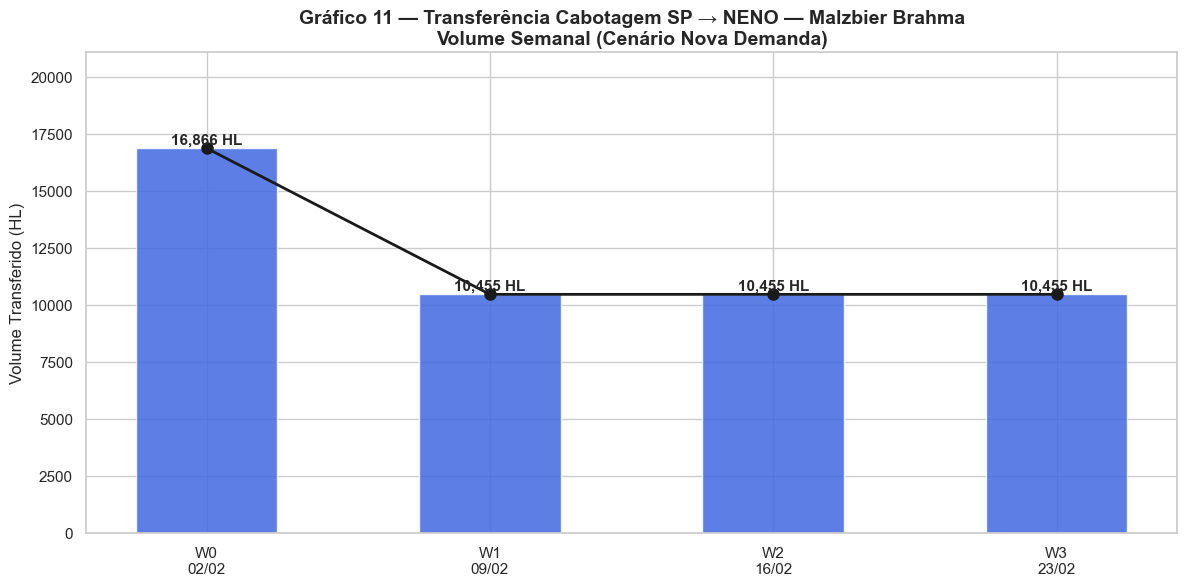


📊 INSIGHT: Total transferido de SP → NENO via cabotagem no mês: 48,231 HL.
   Custo estimado de transferência: R$ 4,079,309 (a R$85/HL).
   A transferência é a principal alavanca para cobrir o gap, mas implica custo logístico relevante.


In [15]:
# Gráfico 11: Transferência externa (cabotagem) Malzbier — SP para NENO
# Row 40 = Malzbier SP, Transf. Ext (Cabo) cols: W0=10, W1=21, W2=32, W3=43
cabo_cols = [10, 21, 32, 43]

# Malzbier SP row 40 — valor é negativo (SP exporta)
malz_sp_cabo = [-cenario_novo.iloc[40, c] for c in cabo_cols]  # Invertemos pois SP envia (negativo)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(semanas, malz_sp_cabo, color=AMBEV_BLUE, edgecolor='white', width=0.5, alpha=0.85)
ax.plot(semanas, malz_sp_cabo, 'o-', color=AMBEV_DARK, linewidth=2, markersize=8)

for i, v in enumerate(malz_sp_cabo):
    ax.text(i, v + 200, f'{v:,.0f} HL', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Volume Transferido (HL)')
ax.set_title('Gráfico 11 — Transferência Cabotagem SP → NENO — Malzbier Brahma\nVolume Semanal (Cenário Nova Demanda)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(malz_sp_cabo) * 1.25)

plt.tight_layout()
plt.show()

total_transf = sum(malz_sp_cabo)
custo_transf = total_transf * custos.iloc[6, 4]
print(f"\n📊 INSIGHT: Total transferido de SP → NENO via cabotagem no mês: {total_transf:,.0f} HL.")
print(f"   Custo estimado de transferência: R$ {custo_transf:,.0f} (a R${custos.iloc[6, 4]:.0f}/HL).")
print(f"   A transferência é a principal alavanca para cobrir o gap, mas implica custo logístico relevante.")

## 16. Estoque Inicial vs Demanda Semanal — Cobertura Malzbier (Sub-Regiões)
O estoque inicial de cada sub-região cobre quantos % da demanda da semana?

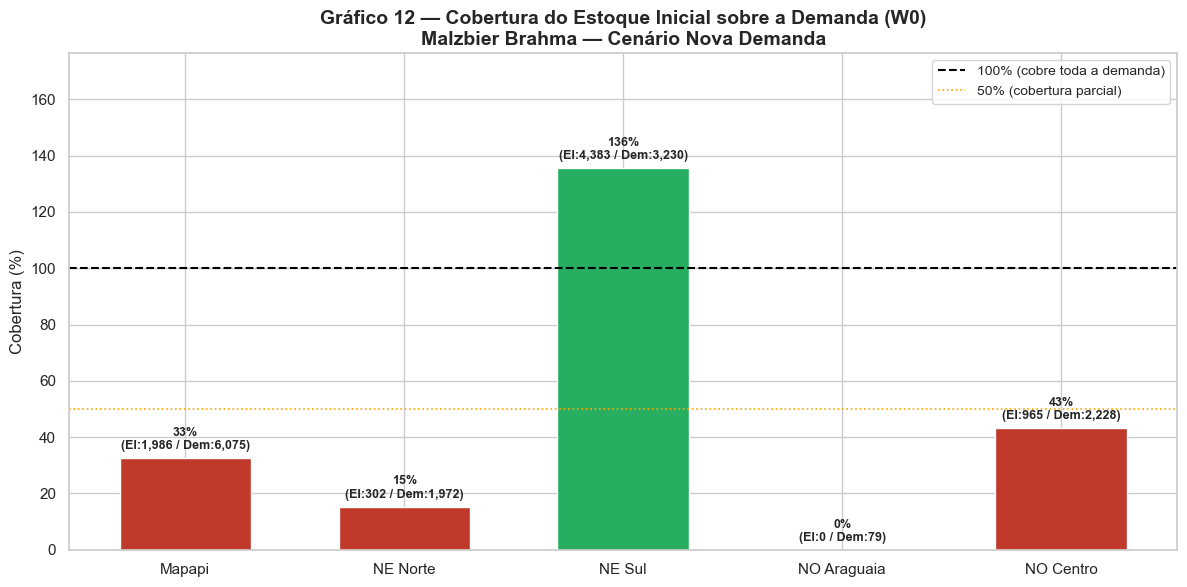


📊 INSIGHT: Sub-regiões com estoque inicial abaixo de 50% da demanda: Mapapi, NE Norte, NO Araguaia, NO Centro.
   Mapapi e NO Centro possuem cobertura muito baixa, indicando dependência total de produção e transferências.
   NO Araguaia tem estoque zero, mas demanda proporcionalmente pequena.


In [16]:
# Gráfico 12: Cobertura do estoque inicial (EI / Demanda) — Malzbier Nova Demanda W0
# EI Semana col=7, Demanda col=3
ei_w0 = [cenario_novo.iloc[r, 7] for r in rows_malz]
dem_w0 = [cenario_novo.iloc[r, 3] for r in rows_malz]
cobertura = [ei / dem * 100 if dem > 0 else 0 for ei, dem in zip(ei_w0, dem_w0)]

fig, ax = plt.subplots(figsize=(12, 6))

colors_cov = [AMBEV_RED if c < 50 else (AMBEV_YELLOW if c < 100 else AMBEV_GREEN) for c in cobertura]
bars = ax.bar(geos, cobertura, color=colors_cov, edgecolor='white', width=0.6)

ax.axhline(y=100, color='black', linestyle='--', linewidth=1.5, label='100% (cobre toda a demanda)')
ax.axhline(y=50, color='orange', linestyle=':', linewidth=1.2, label='50% (cobertura parcial)')

for i, (bar, cov, ei, dem) in enumerate(zip(bars, cobertura, ei_w0, dem_w0)):
    ax.text(bar.get_x() + bar.get_width()/2, cov + 3,
            f'{cov:.0f}%\n(EI:{ei:,.0f} / Dem:{dem:,.0f})',
            ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Cobertura (%)')
ax.set_title('Gráfico 12 — Cobertura do Estoque Inicial sobre a Demanda (W0)\nMalzbier Brahma — Cenário Nova Demanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(cobertura) * 1.3)

plt.tight_layout()
plt.show()

sub_criticas = [g for g, c in zip(geos, cobertura) if c < 50]
print(f"\n📊 INSIGHT: Sub-regiões com estoque inicial abaixo de 50% da demanda: {', '.join(sub_criticas) if sub_criticas else 'nenhuma'}.")
print(f"   Mapapi e NO Centro possuem cobertura muito baixa, indicando dependência total de produção e transferências.")
print(f"   NO Araguaia tem estoque zero, mas demanda proporcionalmente pequena.")

## 17. Demanda Mensal NENO — Janeiro vs Fevereiro (Cenário BR)
A demanda de Long Neck no NENO já vinha crescendo entre meses? Comparação Jan x Fev.

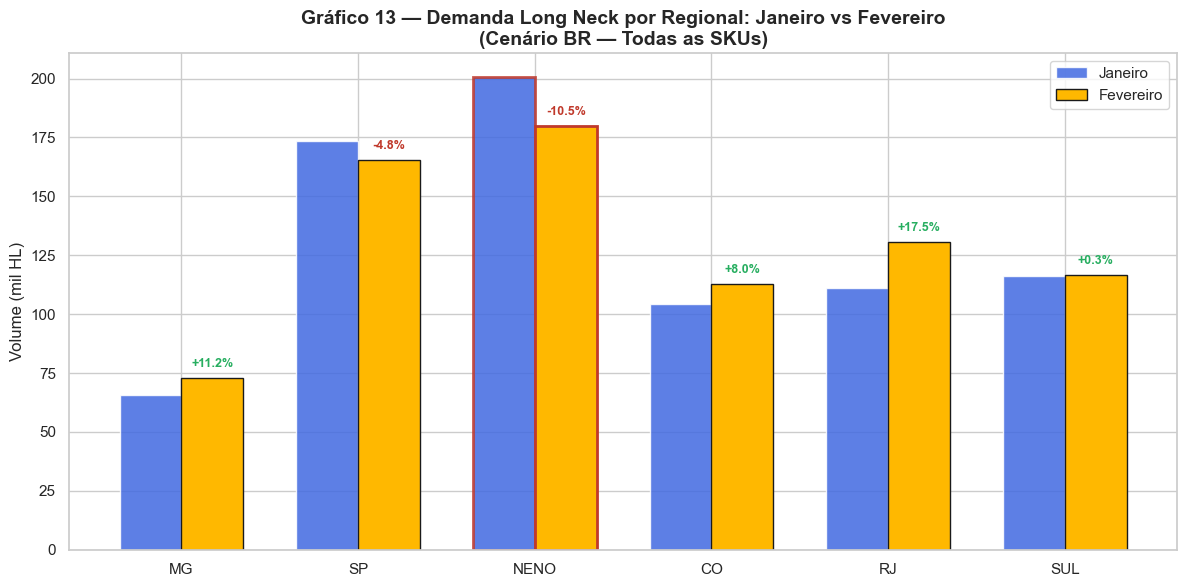


📊 INSIGHT: O NENO teve variação de -10.5% na demanda LN de Janeiro para Fevereiro.
   Demanda Jan: 200,754 HL → Fev: 179,674 HL.
   Mesmo antes do aumento específico da Malzbier, já havia tendência de variação inter-mês.


In [17]:
# Gráfico 13: Demanda LN mensal por região — Janeiro vs Fevereiro (Cenário BR)
regioes_br = ['MG', 'SP', 'NENO', 'CO', 'RJ', 'SUL']
rows_br = [5, 6, 7, 8, 9, 10]

dem_jan = [cenario_br.iloc[r, 3] for r in rows_br]
dem_fev = [cenario_br.iloc[r, 17] for r in rows_br]
var_pct = [(f - j) / j * 100 for j, f in zip(dem_jan, dem_fev)]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(regioes_br))
w = 0.35

ax.bar(x - w/2, [d/1000 for d in dem_jan], w, label='Janeiro', color=AMBEV_BLUE, alpha=0.85)
ax.bar(x + w/2, [d/1000 for d in dem_fev], w, label='Fevereiro', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)

for i in range(len(regioes_br)):
    color_var = AMBEV_RED if var_pct[i] < 0 else AMBEV_GREEN
    ax.annotate(f'{var_pct[i]:+.1f}%', xy=(x[i] + w/2, dem_fev[i]/1000),
                xytext=(0, 8), textcoords='offset points', ha='center',
                fontsize=9, fontweight='bold', color=color_var)

# Destaque NENO
ax.patches[2].set_edgecolor(AMBEV_RED)
ax.patches[2].set_linewidth(2)
ax.patches[2 + len(regioes_br)].set_edgecolor(AMBEV_RED)
ax.patches[2 + len(regioes_br)].set_linewidth(2)

ax.set_xticks(x); ax.set_xticklabels(regioes_br)
ax.set_ylabel('Volume (mil HL)')
ax.set_title('Gráfico 13 — Demanda Long Neck por Regional: Janeiro vs Fevereiro\n(Cenário BR — Todas as SKUs)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

neno_var = var_pct[2]
print(f"\n📊 INSIGHT: O NENO teve variação de {neno_var:+.1f}% na demanda LN de Janeiro para Fevereiro.")
print(f"   Demanda Jan: {dem_jan[2]:,.0f} HL → Fev: {dem_fev[2]:,.0f} HL.")
print(f"   Mesmo antes do aumento específico da Malzbier, já havia tendência de variação inter-mês.")

## 18. Suficiência Final (Fev) por Região — Cenário BR
Panorama da suficiência de estoque final de fevereiro para Long Neck, por regional.

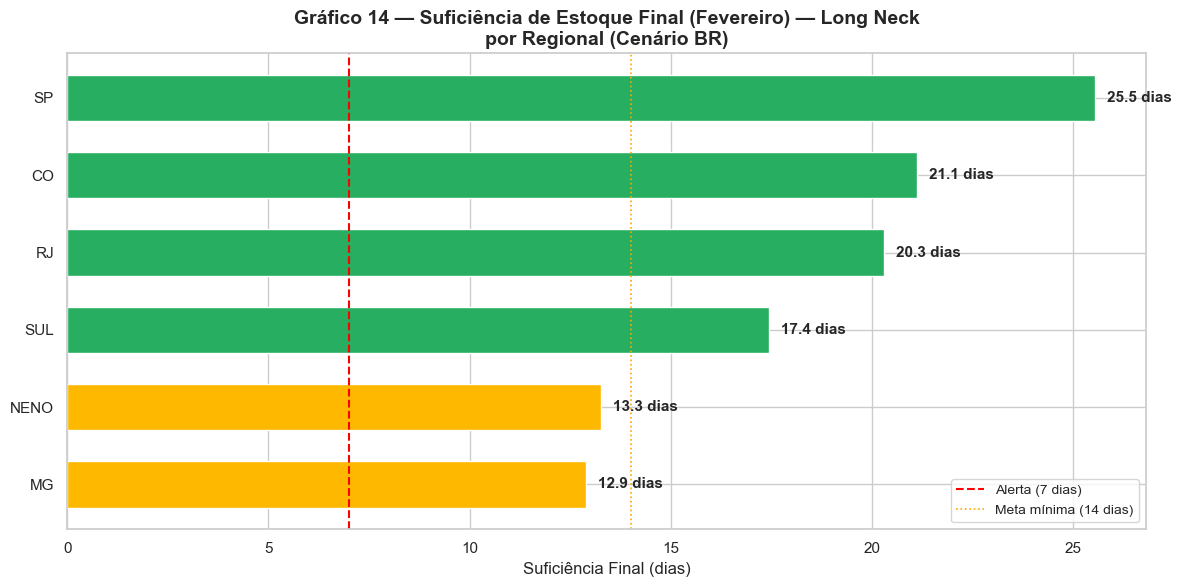


📊 INSIGHT: O NENO encerra fevereiro com suficiência de 13.3 dias.
   Regionais abaixo de 14 dias de suficiência: MG, NENO
   NENO e MG são as regionais com menor cobertura, mais vulneráveis a aumentos de demanda.


In [18]:
# Gráfico 14: Suficiência final Fevereiro por região (Cenário BR)
# Suficiência Fev col=23
suf_fev = [cenario_br.iloc[r, 23] for r in rows_br]

fig, ax = plt.subplots(figsize=(12, 6))

colors_suf = [AMBEV_RED if s < 7 else (AMBEV_YELLOW if s < 14 else AMBEV_GREEN) for s in suf_fev]
sorted_idx = np.argsort(suf_fev)

bars = ax.barh([regioes_br[i] for i in sorted_idx], [suf_fev[i] for i in sorted_idx],
               color=[colors_suf[i] for i in sorted_idx], edgecolor='white', height=0.6)

ax.axvline(x=7, color='red', linestyle='--', linewidth=1.5, label='Alerta (7 dias)')
ax.axvline(x=14, color='orange', linestyle=':', linewidth=1.2, label='Meta mínima (14 dias)')

for i, idx in enumerate(sorted_idx):
    ax.text(suf_fev[idx] + 0.3, i, f'{suf_fev[idx]:.1f} dias', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Suficiência Final (dias)')
ax.set_title('Gráfico 14 — Suficiência de Estoque Final (Fevereiro) — Long Neck\npor Regional (Cenário BR)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

neno_suf = suf_fev[2]
print(f"\n📊 INSIGHT: O NENO encerra fevereiro com suficiência de {neno_suf:.1f} dias.")
regioes_criticas = [r for r, s in zip(regioes_br, suf_fev) if s < 14]
print(f"   Regionais abaixo de 14 dias de suficiência: {', '.join(regioes_criticas)}")
print(f"   NENO e MG são as regionais com menor cobertura, mais vulneráveis a aumentos de demanda.")